In [ ]:
# ============================================================
# SETUP - Run this cell first
# ============================================================
!git clone https://github.com/tatipar/temporalgnn-nids.git
import sys
sys.path.append('/content/temporalgnn-nids/code/python')

from google.colab import drive
drive.mount('/content/drive')
import os
os.chdir('/content/drive/MyDrive/nids-mitre/')

In [ ]:
!pip install torch_geometric

In [ ]:
import os
import glob
import re
import json
import numpy as np
import pandas as pd
import random
import time
from math import pi

import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns

from torch_geometric.loader import DataLoader


In [ ]:
from utils.datasets      import NF_IDS_Dataset
from utils.models        import SimpleMLP, EdgeGRU_Baseline, StaticGNN_Identity, ST_GNN_Identity
from utils.metrics       import calculate_metrics_gnn
from utils.training      import evaluate
from utils.visualization import plot_comparison, plot_radar_chart, MODEL_COLORS
from utils.evaluation import (extract_seed, gather_metrics,
                              apply_1sd_rule, evaluate_test2,
                              generate_summary_table)


# Auxiliary

In [ ]:
ROOT_PATH = "./dataset_processed_thu0103"

In [ ]:
# Instantiate Dataset (Only reads file names)
test2_dataset = NF_IDS_Dataset(root_dir=ROOT_PATH, split='test2')

print(f"Test2 size: {len(test2_dataset)}")

# Instantiate DataLoader (Load manager)
test2_loader = DataLoader(test2_dataset, batch_size=1, shuffle=False, num_workers=2, persistent_workers=True, pin_memory=False)



Test2 size: 2822


In [ ]:
BASE_RESULTS_PATH = "./results_earlystopping/"

RESULTS_TEST_DIRNAME="test2_results"
TEST2_DIR = os.path.join(BASE_RESULTS_PATH, RESULTS_TEST_DIRNAME)

MODEL_NAME_MAPPING = {
    'SimpleMLP_BiasOn': 'Simple MLP',
    'EdgeGRU_BiasOn': 'Edge GRU',
    'StaticGNN_BiasOn_robust_Identity': 'Static GNN',
    'ST_GNN_BiasOn_robust_Identity_clone': 'ST-GNN (Ours)'
}


In [ ]:
sns.set_theme(style="whitegrid")

colors = {
    "Simple MLP": "#95a5a6",   # Gray
    "Edge GRU": "#3498db",   # Blue
    "Static GNN": "#e67e22",     # Orange
    "ST-GNN (Ours)": "#2ecc71" # Green
}


# Main

In [ ]:
# --- PARAMETERS ---
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")

EPOCHS = 60
BATCH_STEPS = 10 # backprop every 10 snapshots (sequence)
LR = 0.005
POS_WEIGHT = 2.0

NODE_DIM = 16   # Features dummy (1s)
EDGE_DIM = 32   # 20 numeric + 7 dst_port + 5 protocol
HIDDEN_DIM = 32
DROPOUT = 0.2
BIAS_VALUE = -2.9968

#PROB_THRESHOLD = 0.5



Using device: cpu


In [ ]:
model_config = {
    "model_name": None,
    "type": None,
    "model_params": {
        "node_dim": NODE_DIM,
        "edge_dim": EDGE_DIM,
        "hidden_dim": HIDDEN_DIM,
        "dropout": DROPOUT,
        "output_bias_init": BIAS_VALUE
    },
    #"prob_threshold": PROB_THRESHOLD,
    "extra_params": {
        "epochs": EPOCHS,
        "batch_steps": BATCH_STEPS,
        "pos_weight": POS_WEIGHT,
        "learning_rate": LR
    }
}

In [ ]:
df_all_metrics = gather_metrics(os.path.join(BASE_RESULTS_PATH,"logs"), MODEL_NAME_MAPPING)

if len(df_all_metrics) > 0:
    df_champions = apply_1sd_rule(df_all_metrics)
    print("\n" + "="*100)
    print(df_champions.to_string(index=False))
    print("="*100)
else:
    print(" The data could not be extracted. Please review the CSV and JSON files.")

                       SELECTION OF CHAMPIONS (RULE 1-SD)                       

Architecture: SIMPLE MLP (Seeds analyzed: 5)
  -> F1 Range   : Max = 0.2680 | Std = 0.0223
  -> Zone 1-SD: Models with F1 >= 0.2457
  -> Candidates : 2 seed(s) entered the safe zone.
     CHAMPION   : Seed 777 | F1: 0.2680 | Training epochs: 59

Architecture: EDGE GRU (Seeds analyzed: 5)
  -> F1 Range   : Max = 0.3465 | Std = 0.0457
  -> Zone 1-SD: Models with F1 >= 0.3008
  -> Candidates : 2 seed(s) entered the safe zone.
     CHAMPION   : Seed 42 | F1: 0.3071 | Training epochs: 31

Architecture: STATIC GNN (Seeds analyzed: 5)
  -> F1 Range   : Max = 0.4905 | Std = 0.1003
  -> Zone 1-SD: Models with F1 >= 0.3903
  -> Candidates : 4 seed(s) entered the safe zone.
     CHAMPION   : Seed 42 | F1: 0.4905 | Training epochs: 52

Architecture: ST-GNN (OURS) (Seeds analyzed: 5)
  -> F1 Range   : Max = 0.7727 | Std = 0.0183
  -> Zone 1-SD: Models with F1 >= 0.7544
  -> Candidates : 3 seed(s) entered the safe zone

In [ ]:
pairs = [(SimpleMLP, "SimpleMLP_BiasOn"),
          (EdgeGRU_Baseline, "EdgeGRU_BiasOn"),
          (StaticGNN_Identity, "StaticGNN_BiasOn_robust_Identity"),
          (ST_GNN_Identity, "ST_GNN_BiasOn_robust_Identity_clone")]

In [ ]:
all_results_dfs = []
for i, (mclass, exp_name) in enumerate(pairs):
    # Filter df_champions to get only the champion for the current experiment type
    filtered_champions = df_champions[df_champions['Raw_Dir_Name'] == exp_name]

    # Ensure filtered_champions is not empty before proceeding
    if not filtered_champions.empty:
        current_df = evaluate_test2(mclass, model_config, test2_loader, exp_name, filtered_champions, DEVICE, BASE_RESULTS_PATH, RESULTS_TEST_DIRNAME, True)
        if not current_df.empty:
            all_results_dfs.append(current_df)


if all_results_dfs:
    final_combined_df = pd.concat(all_results_dfs, ignore_index=True)
    # Extract the base model name by splitting at '_seed' and then apply the mapping
    final_combined_df['model'] = final_combined_df['model_name'].apply(lambda x: MODEL_NAME_MAPPING.get(x.split('_seed')[0], x.split('_seed')[0]))
    print("\nAll evaluation results combined")

    # Save the combined DataFrame to a single CSV file
    output_filepath = os.path.join(BASE_RESULTS_PATH, RESULTS_TEST_DIRNAME, "test2_combined_metrics.csv")
    final_combined_df.to_csv(output_filepath, index=False, float_format='%.16g')
    print(f"\nAll combined Test 2 results saved to: {output_filepath}")
else:
    print("No evaluation results were generated.")


Evaluating: SimpleMLP_BiasOn_seed777
 Precision: 0.8805 | Recall: 0.3226 | F1: 0.4722 | F2: 0.3694 | AUC-PR: 0.3961 | AUC-ROC: 0.8112 | FPR: 0.0022

------------------------------------------------------------

Evaluating: EdgeGRU_BiasOn_seed42
 Precision: 0.3798 | Recall: 0.3952 | F1: 0.3873 | F2: 0.3920 | AUC-PR: 0.4297 | AUC-ROC: 0.8372 | FPR: 0.0330

------------------------------------------------------------

Evaluating: StaticGNN_BiasOn_robust_Identity_seed42
 Precision: 0.5094 | Recall: 0.2071 | F1: 0.2944 | F2: 0.2349 | AUC-PR: 0.3142 | AUC-ROC: 0.8355 | FPR: 0.0102

------------------------------------------------------------

Evaluating: ST_GNN_BiasOn_robust_Identity_clone_seed42
 Precision: 0.6336 | Recall: 0.9419 | F1: 0.7576 | F2: 0.8584 | AUC-PR: 0.8384 | AUC-ROC: 0.9830 | FPR: 0.0278

------------------------------------------------------------

All evaluation results combined

All combined Test 2 results saved to: ./results_earlystopping/test2_results/test2_combined_m

In [ ]:
final_combined_df

,Precision,Recall,F1,F2,AUC-PR,AUC-ROC,FPR,TP,FP,TN,FN,optimal_threshold,seed,run_id,model_name,type,model
0,0.880465,0.322581,0.472171,0.369392,0.396098,0.811167,0.002238,33492,4547,2027585,70333,0.455980,777,SimpleMLP_BiasOn_seed777_20260219_185137,SimpleMLP_BiasOn_seed777,SimpleMLP,Simple MLP
1,0.379767,0.395184,0.387322,0.392001,0.429702,0.837231,0.032975,41030,67010,1965122,62795,0.272351,42,EdgeGRU_BiasOn_seed42_20260220_115040,EdgeGRU_BiasOn_seed42,EdgeGRU_Baseline,Edge GRU
2,0.509359,0.207050,0.294421,0.234938,0.314211,0.835520,0.010190,21497,20707,2011425,82328,0.393601,42,StaticGNN_BiasOn_robust_Identity_seed42_202602...,StaticGNN_BiasOn_robust_Identity_seed42,SaticGNN_Identity,Static GNN
3,0.633625,0.941902,0.757604,0.858377,0.838383,0.983031,0.027826,97793,56546,1975586,6032,0.203219,42,ST_GNN_BiasOn_robust_Identity_clone_seed42_202...,ST_GNN_BiasOn_robust_Identity_clone_seed42,ST_GNN_Identity,ST-GNN (Ours)


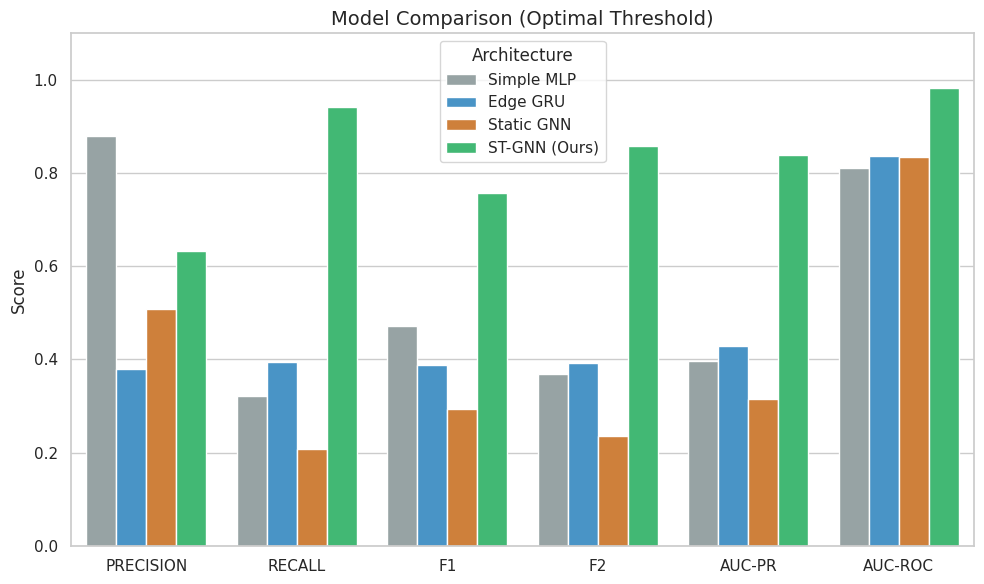

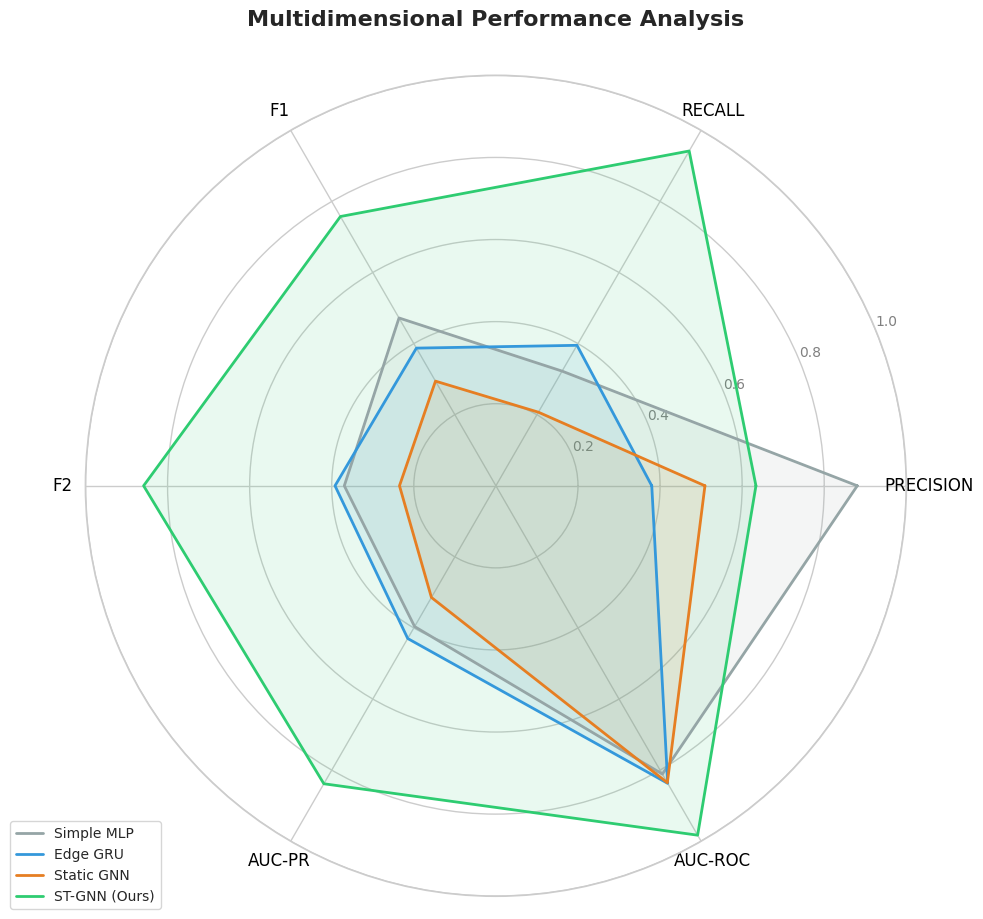

In [ ]:
plot_comparison(final_combined_df, TEST2_DIR)

plot_radar_chart(final_combined_df, TEST2_DIR)